# 🏥 DSO1 — Prédiction du Risque de Complication
## MediFollow - Modélisation Machine Learning

**Objectif** : Classifier les patients selon leur risque de complication post-hospitalisation.

**Modèles** : Régression Logistique, Random Forest, XGBoost ✅ (retenu), SVM

---

## 📦 Imports & Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
import os, time, warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

DATASETS_DIR = os.path.join(os.getcwd(), 'datasets')
print('✅ Imports OK')

✅ Imports OK


You can create the `datasets` directory and move the files into it using the following commands:

In [6]:
import os

# Create the datasets directory if it doesn't exist
if not os.path.exists(DATASETS_DIR):
    os.makedirs(DATASETS_DIR)
    print(f"Directory '{DATASETS_DIR}' created.")

# List files in the current directory to identify the dataset files
current_files = [f for f in os.listdir('/content/') if f.endswith('.csv') and f.startswith('dataset_')]

# Move the dataset files to the DATASETS_DIR
for filename in current_files:
    src_path = os.path.join('/content/', filename)
    dst_path = os.path.join(DATASETS_DIR, filename)
    if os.path.exists(src_path):
        os.rename(src_path, dst_path)
        print(f"Moved '{filename}' to '{DATASETS_DIR}'.")
    else:
        print(f"'{filename}' not found in '/content/'.")

# Verify files are in the new directory
print(f"\nFiles in '{DATASETS_DIR}':")
print(os.listdir(DATASETS_DIR))

Directory '/content/datasets' created.
Moved 'dataset_after_cleaning.csv' to '/content/datasets'.
Moved 'dataset_before_cleaning .csv' to '/content/datasets'.

Files in '/content/datasets':
['dataset_after_cleaning.csv', 'dataset_before_cleaning .csv']


---
## 📁 Étape 1 : Dataset Before Cleaning (Données Brutes)

In [11]:
df_raw = pd.read_csv(os.path.join(DATASETS_DIR, 'dataset_before_cleaning .csv'))
print(f"Shape: {df_raw.shape}")
df_raw.head(10)

Shape: (1020, 20)


,age,sexe,imc,nb_comorbidites,freq_cardiaque,pa_systolique,pa_diastolique,spo2,temperature,glycemie,nb_hospitalisations,duree_derniere_hospit,nb_medicaments,observance,score_autonomie,nb_consultations_mois,risque_complication,niveau_risque,comorbidites,antecedents
0,69,0,31.044205,1,94.948917,132,93.456624,99.450083,36.900104,0.822508,2,9,5.0,0.901653,7,2,0,eleve,HTA,chirurgie
1,32,0,30.747128,3,85.518171,120,94.499585,97.627445,36.675634,0.707877,1,3,8.0,0.915473,0,0,1,eleve,diabete,infection
2,89,1,32.577668,3,93.345725,106,72.639886,97.166572,36.776197,0.890468,1,14,8.0,0.776640,6,3,1,moyen,diabete,chirurgie
3,78,0,20.095753,1,79.977271,143,94.088496,97.344646,36.484587,1.356221,1,8,8.0,0.228331,6,0,1,eleve,aucune,chirurgie
4,38,0,32.346711,2,81.401020,151,61.637358,99.869985,37.848989,0.867457,0,6,2.0,0.024809,8,1,0,eleve,aucune,infection
5,41,0,24.867257,2,65.775505,121,61.986460,98.639006,37.043486,0.892702,2,4,8.0,0.383774,1,2,1,faible,aucune,aucun
6,20,0,26.779011,3,91.359494,129,84.940768,94.637595,36.026819,0.803919,2,12,5.0,0.141549,2,1,0,faible,HTA,infection
7,39,1,36.875698,3,76.775584,102,62.524255,98.670570,36.038893,1.272349,0,12,1.0,0.710388,3,3,1,moyen,aucune,chirurgie
8,70,0,18.198669,0,80.003205,124,72.984367,95.023228,37.945923,0.755339,2,9,7.0,0.661131,0,3,0,eleve,aucune,aucun
9,19,0,30.945078,2,91.403909,94,86.910239,96.684103,36.442902,0.964967,1,5,6.0,0.043972,6,4,0,faible,diabete,infection


In [12]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1020 non-null   int64  
 1   sexe                   1020 non-null   int64  
 2   imc                    971 non-null    float64
 3   nb_comorbidites        1020 non-null   int64  
 4   freq_cardiaque         970 non-null    float64
 5   pa_systolique          1020 non-null   int64  
 6   pa_diastolique         1020 non-null   float64
 7   spo2                   1020 non-null   float64
 8   temperature            1020 non-null   float64
 9   glycemie               1020 non-null   float64
 10  nb_hospitalisations    1020 non-null   int64  
 11  duree_derniere_hospit  1020 non-null   int64  
 12  nb_medicaments         1020 non-null   float64
 13  observance             1020 non-null   float64
 14  score_autonomie        1020 non-null   int64  
 15  nb_c

In [13]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_report = pd.DataFrame({'Manquantes': missing, '%': missing_pct})
missing_report = missing_report[missing_report['Manquantes'] > 0].sort_values('Manquantes', ascending=False)
print(f"Total valeurs manquantes : {missing.sum()}")
print(f"Doublons : {df_raw.duplicated().sum()}")
missing_report

Total valeurs manquantes : 99
Doublons : 20


,Manquantes,%
freq_cardiaque,50,4.9
imc,49,4.8


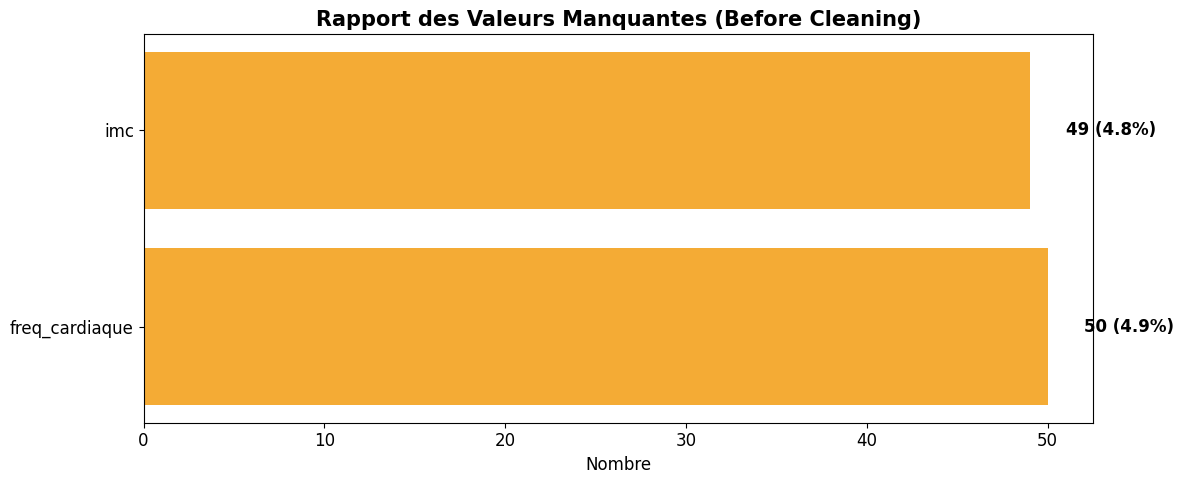

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if p > 5 else '#f39c12' if p > 3 else '#3498db' for p in missing_report['%']]
bars = ax.barh(missing_report.index, missing_report['Manquantes'], color=colors, alpha=0.85)
ax.set_title('Rapport des Valeurs Manquantes (Before Cleaning)', fontsize=15, fontweight='bold')
ax.set_xlabel('Nombre')
for bar, val, pct in zip(bars, missing_report['Manquantes'], missing_report['%']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, f'{val} ({pct}%)', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

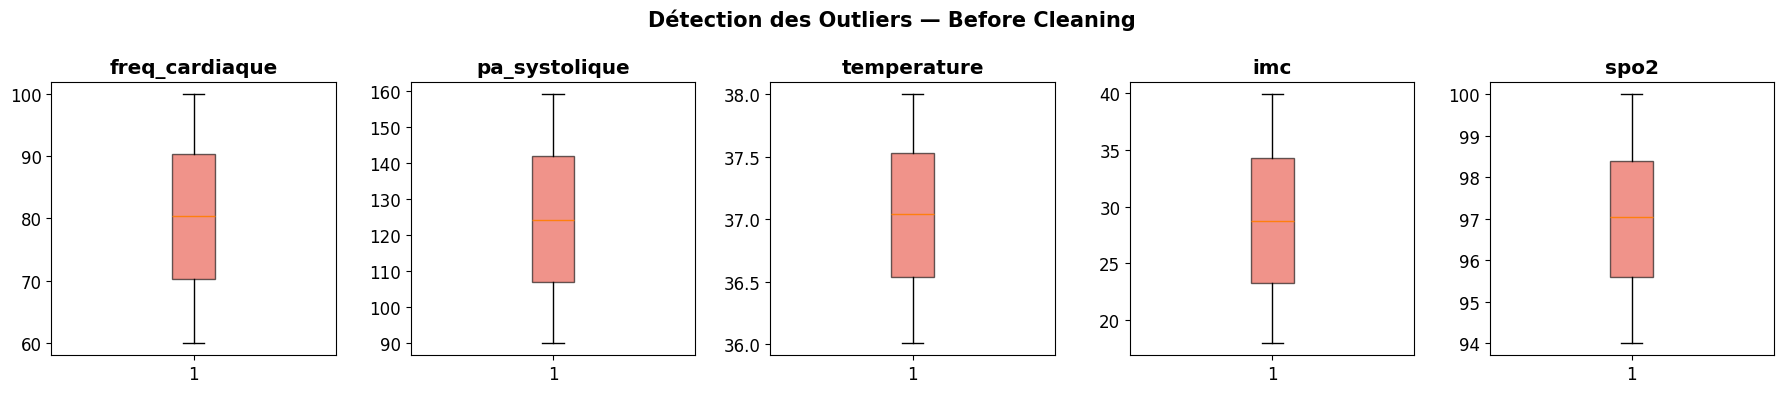

In [15]:
outlier_cols = ['freq_cardiaque', 'pa_systolique', 'temperature', 'imc', 'spo2']
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 4))
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df_raw[col].dropna(), patch_artist=True, boxprops=dict(facecolor='#e74c3c', alpha=0.6))
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Détection des Outliers — Before Cleaning', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
df_raw.describe()

,age,sexe,imc,nb_comorbidites,freq_cardiaque,pa_systolique,pa_diastolique,spo2,temperature,glycemie,nb_hospitalisations,duree_derniere_hospit,nb_medicaments,observance,score_autonomie,nb_consultations_mois,risque_complication
count,1020.000000,1020.000000,971.000000,1020.000000,970.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000
mean,53.002941,0.499020,28.806484,1.986275,80.183521,124.204902,79.519725,97.003853,37.024927,1.100032,0.992157,7.409804,5.066667,0.499371,4.415686,1.944118,0.316667
std,20.953779,0.500244,6.261033,1.418305,11.435766,20.124738,11.792514,1.700099,0.580459,0.233799,0.810830,4.011111,2.551427,0.294454,2.851880,1.403701,0.465404
min,18.000000,0.000000,18.004145,0.000000,60.053851,90.000000,60.025101,94.007608,36.010158,0.701084,0.000000,1.000000,1.000000,0.000158,0.000000,0.000000,0.000000
25%,35.000000,0.000000,23.234730,1.000000,70.340815,107.000000,69.285698,95.593546,36.541044,0.898870,0.000000,4.000000,3.000000,0.244404,2.000000,1.000000,0.000000
50%,53.000000,0.000000,28.744242,2.000000,80.465486,124.000000,78.972412,97.049573,37.043870,1.099975,1.000000,7.000000,5.000000,0.482119,4.000000,2.000000,0.000000
75%,71.000000,1.000000,34.251002,3.000000,90.322663,142.000000,89.858627,98.397089,37.530144,1.306759,2.000000,11.000000,7.000000,0.763779,7.000000,3.000000,1.000000
max,89.000000,1.000000,39.900571,4.000000,99.904913,159.000000,99.961980,99.999095,37.999483,1.499766,2.000000,14.000000,9.000000,0.999335,9.000000,4.000000,1.000000


---
## 🧹 Étape 2 : Dataset After Cleaning

In [17]:
df_clean = pd.read_csv(os.path.join(DATASETS_DIR, 'dataset_after_cleaning.csv'))
print(f"Shape avant : {df_raw.shape}  →  après : {df_clean.shape}")
print(f"Valeurs manquantes : {df_clean.isnull().sum().sum()}")
print(f"Doublons : {df_clean.duplicated().sum()}")
df_clean.head(10)

Shape avant : (1020, 20)  →  après : (906, 17)
Valeurs manquantes : 0
Doublons : 0


,age,sexe,imc,nb_comorbidites,freq_cardiaque,pa_systolique,pa_diastolique,spo2,temperature,glycemie,nb_hospitalisations,duree_derniere_hospit,nb_medicaments,observance,score_autonomie,nb_consultations_mois,risque_complication
0,69,0,31.044205,1,94.948917,132,93.456624,99.450083,36.900104,0.822508,2,9,5.0,0.901653,7,2,0
1,32,0,30.747128,3,85.518171,120,94.499585,97.627445,36.675634,0.707877,1,3,8.0,0.915473,0,0,1
2,89,1,32.577668,3,93.345725,106,72.639886,97.166572,36.776197,0.890468,1,14,8.0,0.776640,6,3,1
3,78,0,20.095753,1,79.977271,143,94.088496,97.344646,36.484587,1.356221,1,8,8.0,0.228331,6,0,1
4,38,0,32.346711,2,81.401020,151,61.637358,99.869985,37.848989,0.867457,0,6,2.0,0.024809,8,1,0
5,41,0,24.867257,2,65.775505,121,61.986460,98.639006,37.043486,0.892702,2,4,8.0,0.383774,1,2,1
6,20,0,26.779011,3,91.359494,129,84.940768,94.637595,36.026819,0.803919,2,12,5.0,0.141549,2,1,0
7,39,1,36.875698,3,76.775584,102,62.524255,98.670570,36.038893,1.272349,0,12,1.0,0.710388,3,3,1
8,70,0,18.198669,0,80.003205,124,72.984367,95.023228,37.945923,0.755339,2,9,7.0,0.661131,0,3,0
9,19,0,30.945078,2,91.403909,94,86.910239,96.684103,36.442902,0.964967,1,5,6.0,0.043972,6,4,0


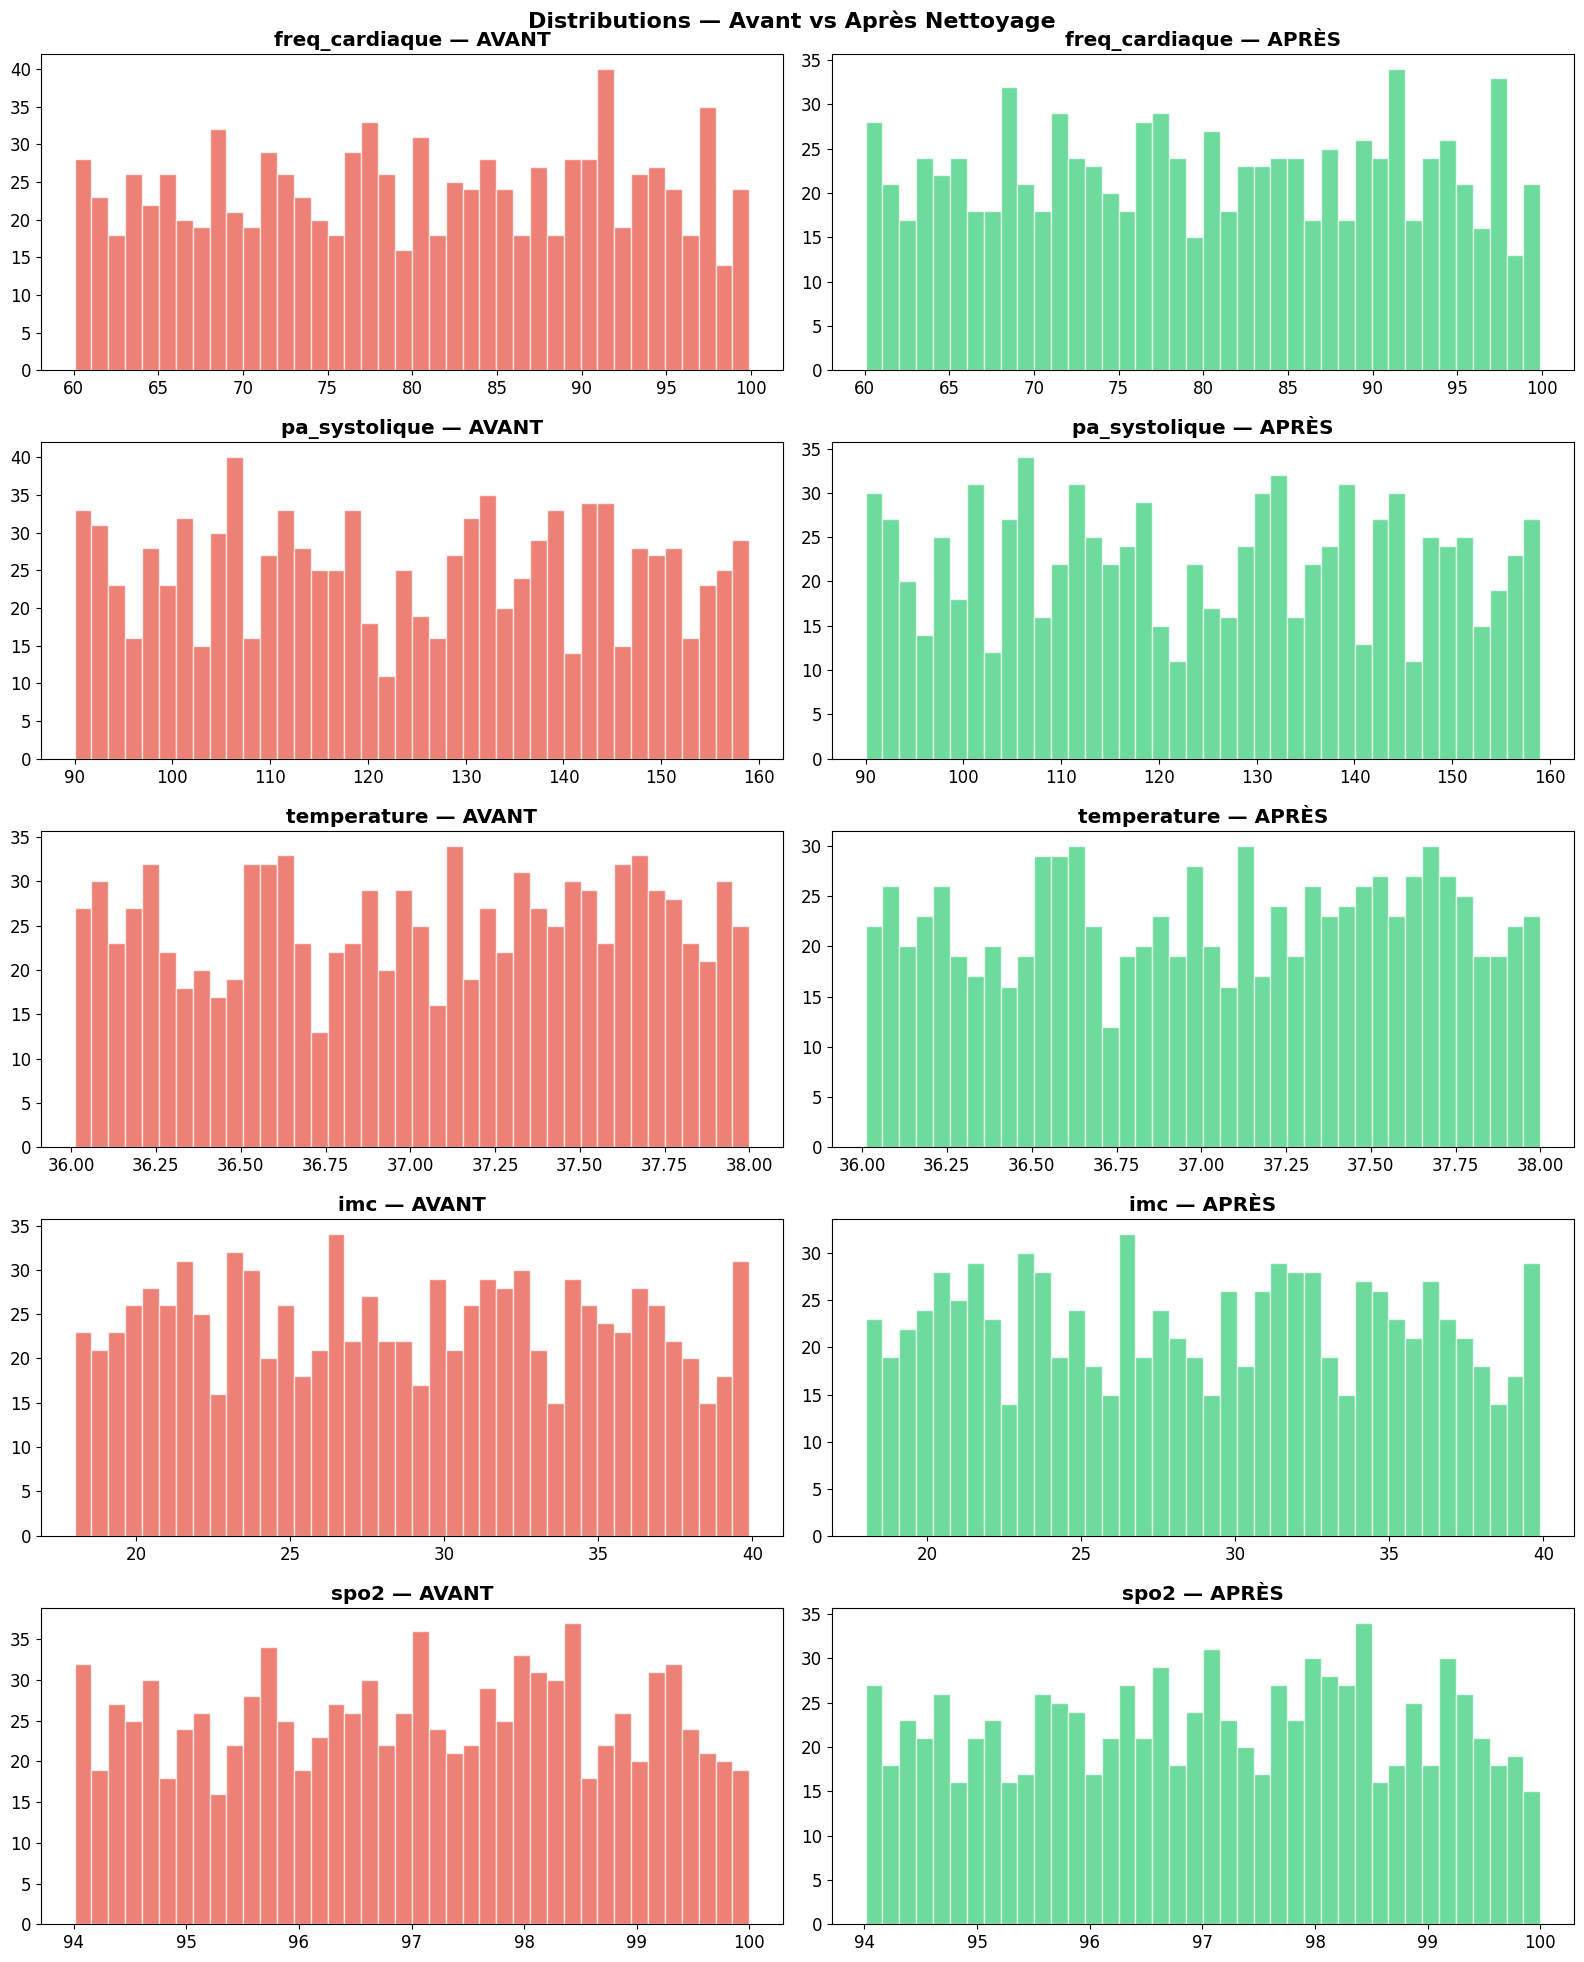

In [18]:
import matplotlib.pyplot as plt

compare_cols = ['freq_cardiaque', 'pa_systolique', 'temperature', 'imc', 'spo2']
fig, axes = plt.subplots(len(compare_cols), 2, figsize=(16, 4 * len(compare_cols)))
for i, col in enumerate(compare_cols):
    axes[i, 0].hist(df_raw[col].dropna(), bins=40, color='#e74c3c', alpha=0.7, edgecolor='white')
    axes[i, 0].set_title(f'{col} — AVANT', fontweight='bold')
    axes[i, 1].hist(df_clean[col], bins=40, color='#2ecc71', alpha=0.7, edgecolor='white')
    axes[i, 1].set_title(f'{col} — APRÈS', fontweight='bold')
plt.suptitle('Distributions — Avant vs Après Nettoyage', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

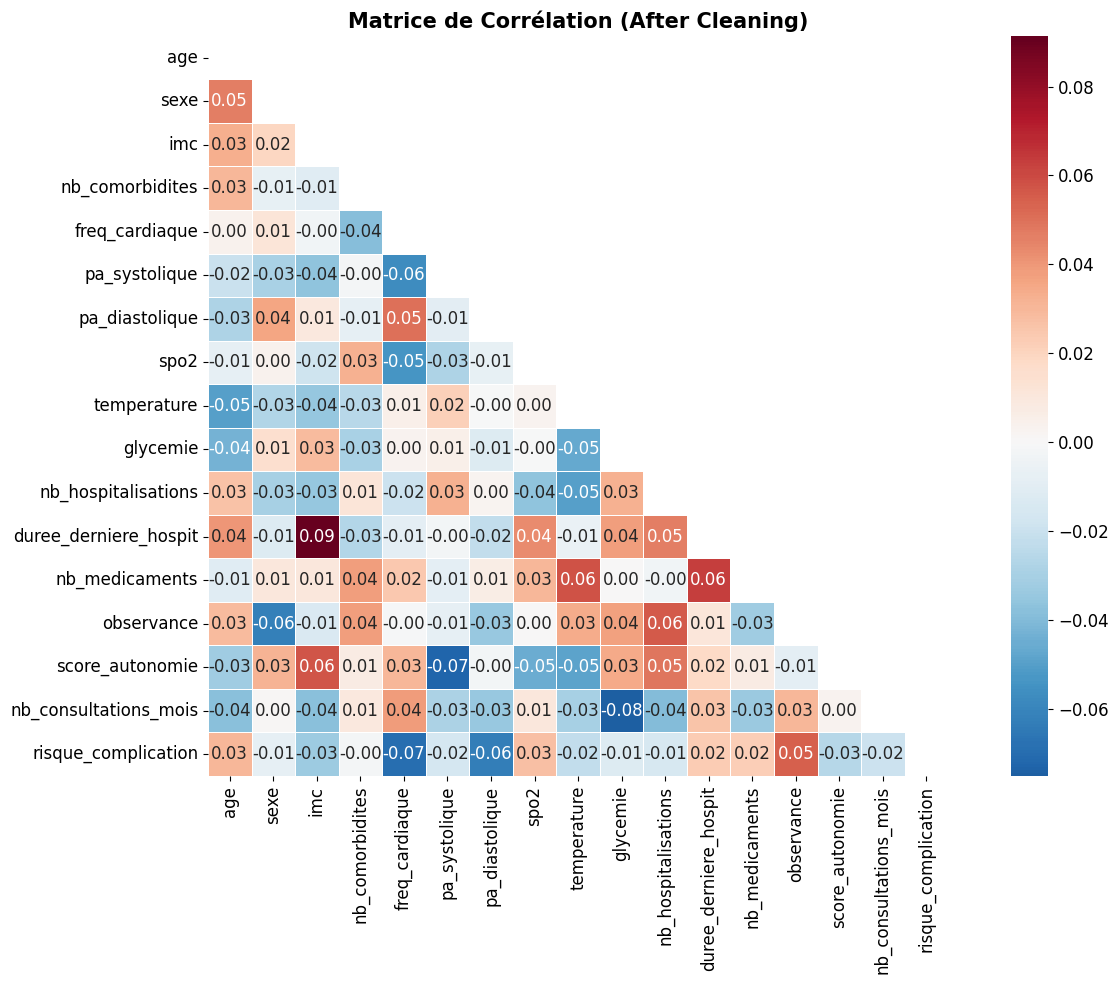

In [19]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(df_clean[num_cols].corr(), dtype=bool))
sns.heatmap(df_clean[num_cols].corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
ax.set_title('Matrice de Corrélation (After Cleaning)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚙️ Étape 3 : Processing (Encodage + Normalisation + SMOTE)

In [21]:
df = df_clean.copy()
le_sexe = LabelEncoder()

# Encode 'sexe' if it exists in the DataFrame
if 'sexe' in df.columns:
    df['sexe_encoded'] = le_sexe.fit_transform(df['sexe'])
    print(f"LabelEncoder sexe: {dict(zip(le_sexe.classes_, le_sexe.transform(le_sexe.classes_)))}")

# 'comorbidites', 'antecedents', and 'niveau_risque' are already absent in df_clean.
# Removing the problematic get_dummies and drop operations for these columns.

columns_to_drop = []
# Only drop 'sexe' if it was present and 'sexe_encoded' was created.
if 'sexe' in df.columns:
    columns_to_drop.append('sexe')

if columns_to_drop: # Ensure there are columns to drop before attempting to drop
    df.drop(columns=columns_to_drop, inplace=True)

print(f"\nShape après encodage: {df.shape}")
df.head()

LabelEncoder sexe: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Shape après encodage: (906, 17)


,age,imc,nb_comorbidites,freq_cardiaque,pa_systolique,pa_diastolique,spo2,temperature,glycemie,nb_hospitalisations,duree_derniere_hospit,nb_medicaments,observance,score_autonomie,nb_consultations_mois,risque_complication,sexe_encoded
0,69,31.044205,1,94.948917,132,93.456624,99.450083,36.900104,0.822508,2,9,5.0,0.901653,7,2,0,0
1,32,30.747128,3,85.518171,120,94.499585,97.627445,36.675634,0.707877,1,3,8.0,0.915473,0,0,1,0
2,89,32.577668,3,93.345725,106,72.639886,97.166572,36.776197,0.890468,1,14,8.0,0.776640,6,3,1,1
3,78,20.095753,1,79.977271,143,94.088496,97.344646,36.484587,1.356221,1,8,8.0,0.228331,6,0,1,0
4,38,32.346711,2,81.401020,151,61.637358,99.869985,37.848989,0.867457,0,6,2.0,0.024809,8,1,0,0


In [22]:
y = df['risque_complication']
X = df.drop(columns=['risque_complication'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
num_features = ['age', 'imc', 'freq_cardiaque', 'pa_systolique', 'pa_diastolique',
                'spo2', 'temperature', 'duree_hospitalisation', 'nb_diagnostics',
                'observance_traitement', 'score_questionnaire']
num_features = [f for f in num_features if f in X_train.columns]
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print(f"Avant SMOTE: {dict(y_train.value_counts())}")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Après SMOTE: {dict(pd.Series(y_train_sm).value_counts())}")
print(f"X_train: {X_train_sm.shape}, X_test: {X_test.shape}")

Avant SMOTE: {0: np.int64(494), 1: np.int64(230)}
Après SMOTE: {1: np.int64(494), 0: np.int64(494)}
X_train: (988, 16), X_test: (182, 16)


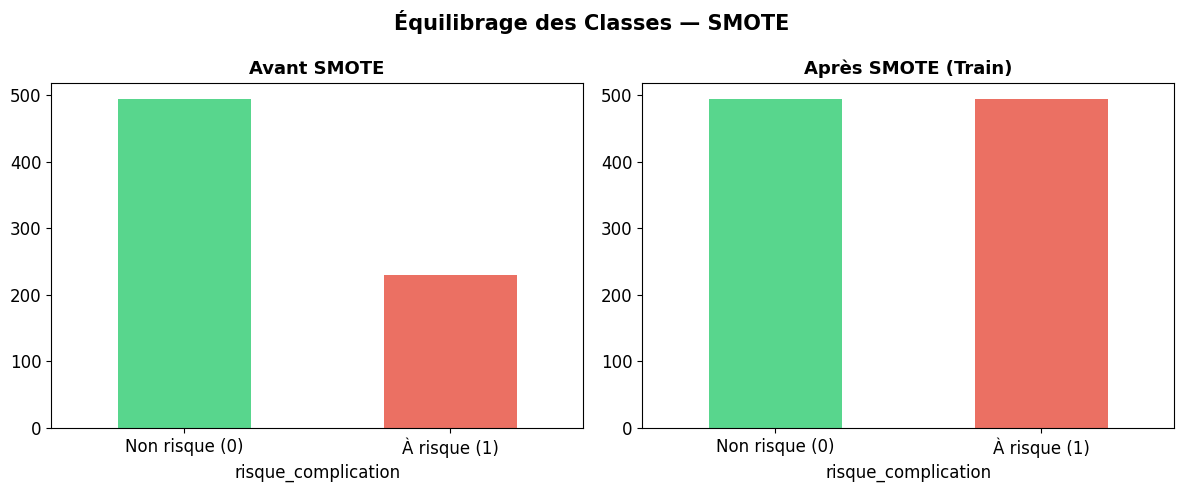

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']
y_train.value_counts().plot(kind='bar', ax=axes[0], color=colors, alpha=0.8)
axes[0].set_title('Avant SMOTE', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Non risque (0)', 'À risque (1)'], rotation=0)
pd.Series(y_train_sm).value_counts().plot(kind='bar', ax=axes[1], color=colors, alpha=0.8)
axes[1].set_title('Après SMOTE (Train)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Non risque (0)', 'À risque (1)'], rotation=0)
plt.suptitle('Équilibrage des Classes — SMOTE', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🤖 Étape 4 : Entraînement des Modèles

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, classification_report, confusion_matrix, roc_curve)

models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                              scale_pos_weight=len(y_train[y_train==0])/max(len(y_train[y_train==1]),1),
                              random_state=42, eval_metric='logloss'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_sm, y_train_sm)
    train_time = time.time() - start
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Modèle': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'Précision': round(precision_score(y_test, y_pred), 4),
        'Rappel': round(recall_score(y_test, y_pred), 4),
        'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4),
        'Temps (s)': round(train_time, 3)
    })
    print(f"✅ {name} — Acc={results[-1]['Accuracy']}, F1={results[-1]['F1-Score']}, AUC={results[-1]['AUC-ROC']}")

df_results = pd.DataFrame(results).set_index('Modèle')
df_results

✅ Régression Logistique — Acc=0.544, F1=0.3759, AUC=0.5348
✅ Random Forest — Acc=0.5934, F1=0.2745, AUC=0.5333
✅ XGBoost — Acc=0.5879, F1=0.4526, AUC=0.5527
✅ SVM — Acc=0.5714, F1=0.4, AUC=0.515


,Accuracy,F1-Score,Précision,Rappel,AUC-ROC,Temps (s)
Modèle,,,,,,
Régression Logistique,0.5440,0.3759,0.3333,0.4310,0.5348,0.025
Random Forest,0.5934,0.2745,0.3182,0.2414,0.5333,0.485
XGBoost,0.5879,0.4526,0.3924,0.5345,0.5527,0.191
SVM,0.5714,0.4000,0.3611,0.4483,0.5150,0.193


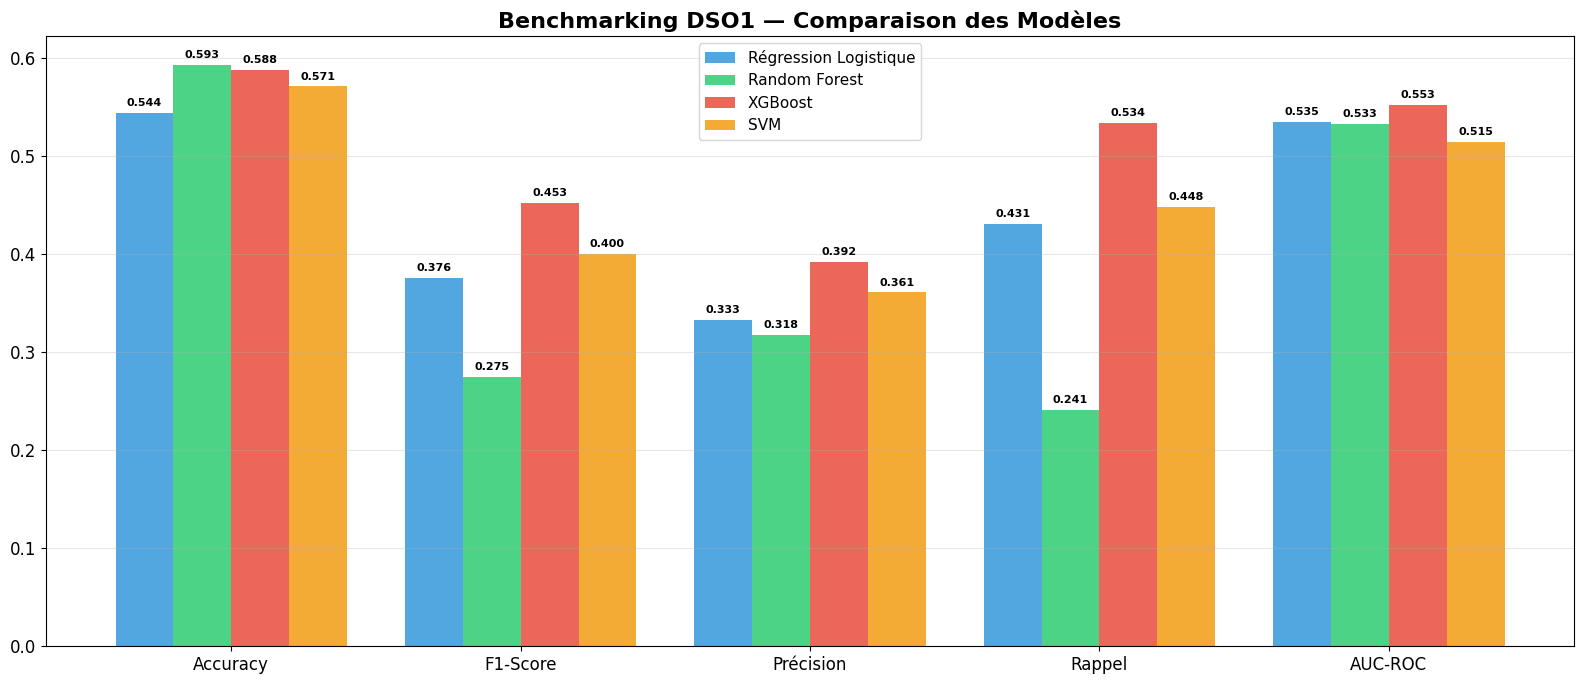

In [25]:
metrics = ['Accuracy', 'F1-Score', 'Précision', 'Rappel', 'AUC-ROC']
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
x = np.arange(len(metrics))
width = 0.2
fig, ax = plt.subplots(figsize=(16, 7))
for i, (model_name, color) in enumerate(zip(df_results.index, colors_bar)):
    vals = [df_results.loc[model_name, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_title('Benchmarking DSO1 — Comparaison des Modèles', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

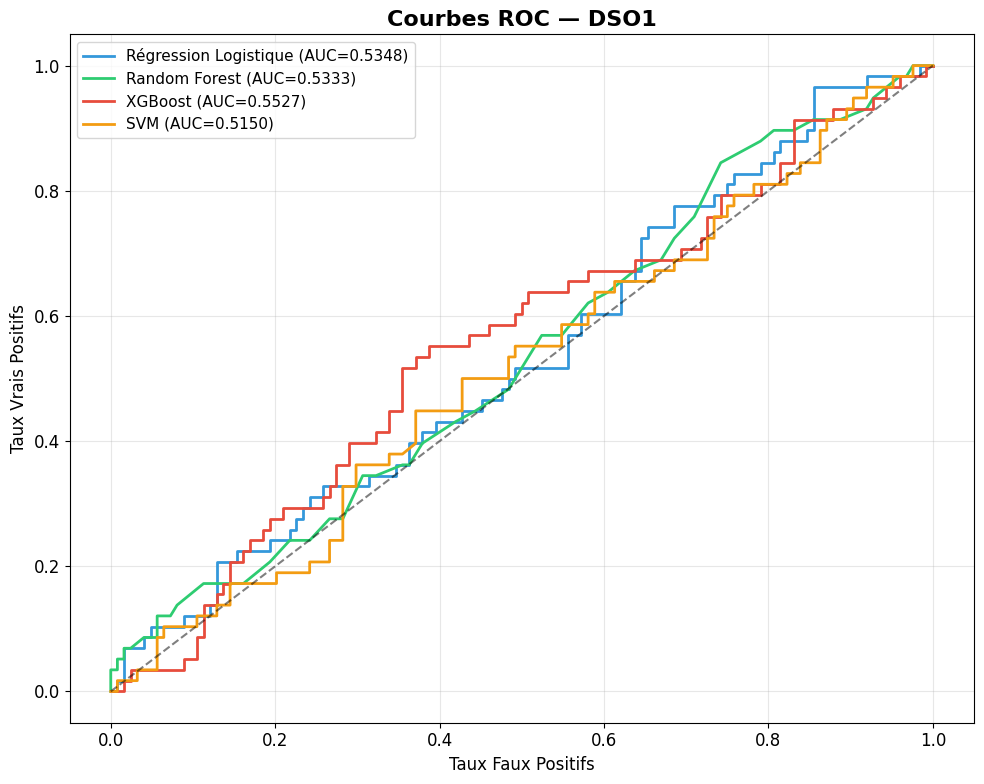

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))
for name, model, color in zip(models.keys(), models.values(), colors_bar):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('Taux Faux Positifs', fontsize=12)
ax.set_ylabel('Taux Vrais Positifs', fontsize=12)
ax.set_title('Courbes ROC — DSO1', fontsize=16, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

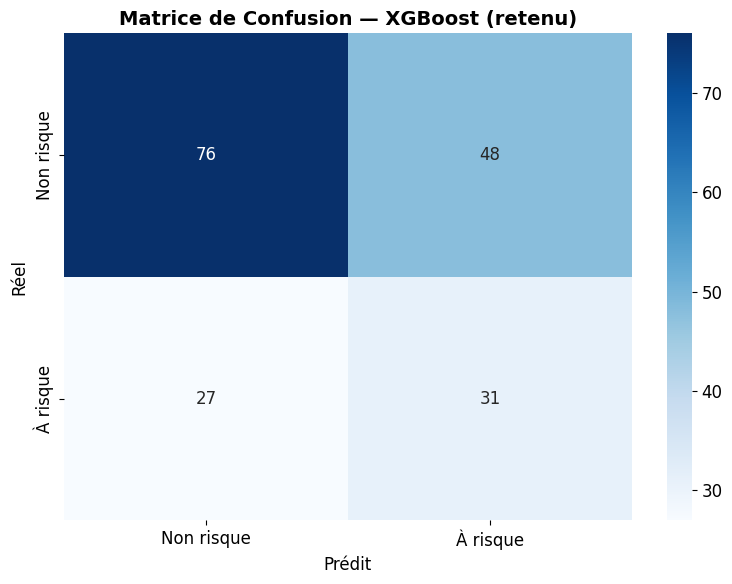

              precision    recall  f1-score   support

  Non risque       0.74      0.61      0.67       124
    À risque       0.39      0.53      0.45        58

    accuracy                           0.59       182
   macro avg       0.57      0.57      0.56       182
weighted avg       0.63      0.59      0.60       182



In [27]:
xgb = models['XGBoost']
y_pred_xgb = xgb.predict(X_test)
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non risque', 'À risque'], yticklabels=['Non risque', 'À risque'])
ax.set_xlabel('Prédit', fontsize=12); ax.set_ylabel('Réel', fontsize=12)
ax.set_title('Matrice de Confusion — XGBoost (retenu)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred_xgb, target_names=['Non risque', 'À risque']))

---
## 🔮 Étape 4bis : Résultats de Prédiction — Détail par Modèle

Pour chaque modèle, nous affichons :
- La **matrice de confusion** détaillée
- Le **rapport de classification** (précision, rappel, F1 par classe)
- Un **échantillon de prédictions** sur des patients réels
- La **probabilité de risque** estimée pour chaque patient

In [28]:
# Fonction utilitaire pour afficher les résultats détaillés d'un modèle
def afficher_resultats_prediction(model, model_name, X_test, y_test, color='#3498db'):
    """
    Affiche les résultats de prédiction détaillés pour un modèle donné.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f'Résultats de Prédiction — {model_name}', fontsize=18, fontweight='bold', y=1.02)

    # 1. Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if color=='#3498db' else 'Greens' if color=='#2ecc71' else 'Oranges' if color=='#e67e22' else 'Reds',
                ax=axes[0], xticklabels=['Non à risque', 'À risque'], yticklabels=['Non à risque', 'À risque'],
                annot_kws={'size': 16})
    axes[0].set_title('Matrice de Confusion', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Prédiction', fontsize=12)
    axes[0].set_ylabel('Réalité', fontsize=12)

    # Annotations
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    axes[0].text(0.5, -0.15, f'Vrais Négatifs: {tn} | Faux Positifs: {fp}\n'
                f'Faux Négatifs: {fn} | Vrais Positifs: {tp}',
                transform=axes[0].transAxes, ha='center', fontsize=10, style='italic')

    # 2. Distribution des probabilités
    axes[1].hist(y_prob[y_test == 0], bins=30, alpha=0.7, label='Non à risque (réel)', color='#2ecc71', edgecolor='white')
    axes[1].hist(y_prob[y_test == 1], bins=30, alpha=0.7, label='À risque (réel)', color='#e74c3c', edgecolor='white')
    axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Seuil = 0.5')
    axes[1].set_xlabel('Probabilité de risque', fontsize=12)
    axes[1].set_ylabel('Nombre de patients', fontsize=12)
    axes[1].set_title('Distribution des Probabilités', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)

    # 3. Courbe ROC individuelle
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[2].plot(fpr, tpr, color=color, linewidth=2.5, label=f'ROC (AUC = {auc:.4f})')
    axes[2].fill_between(fpr, tpr, alpha=0.1, color=color)
    axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[2].set_xlabel('Taux de Faux Positifs', fontsize=12)
    axes[2].set_ylabel('Taux de Vrais Positifs', fontsize=12)
    axes[2].set_title('Courbe ROC', fontsize=14, fontweight='bold')
    axes[2].legend(fontsize=12, loc='lower right')

    plt.tight_layout()
    plt.show()

    # Rapport de classification
    print(f"\n📋 Rapport de Classification — {model_name}")
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=['Non à risque', 'À risque']))

    # Métriques résumées
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    print(f"📊 Résumé: Accuracy={acc:.4f} | F1={f1:.4f} | Précision={prec:.4f} | Rappel={rec:.4f} | AUC={auc:.4f}")

    return y_pred, y_prob

### 📊 1. Régression Logistique — Prédictions

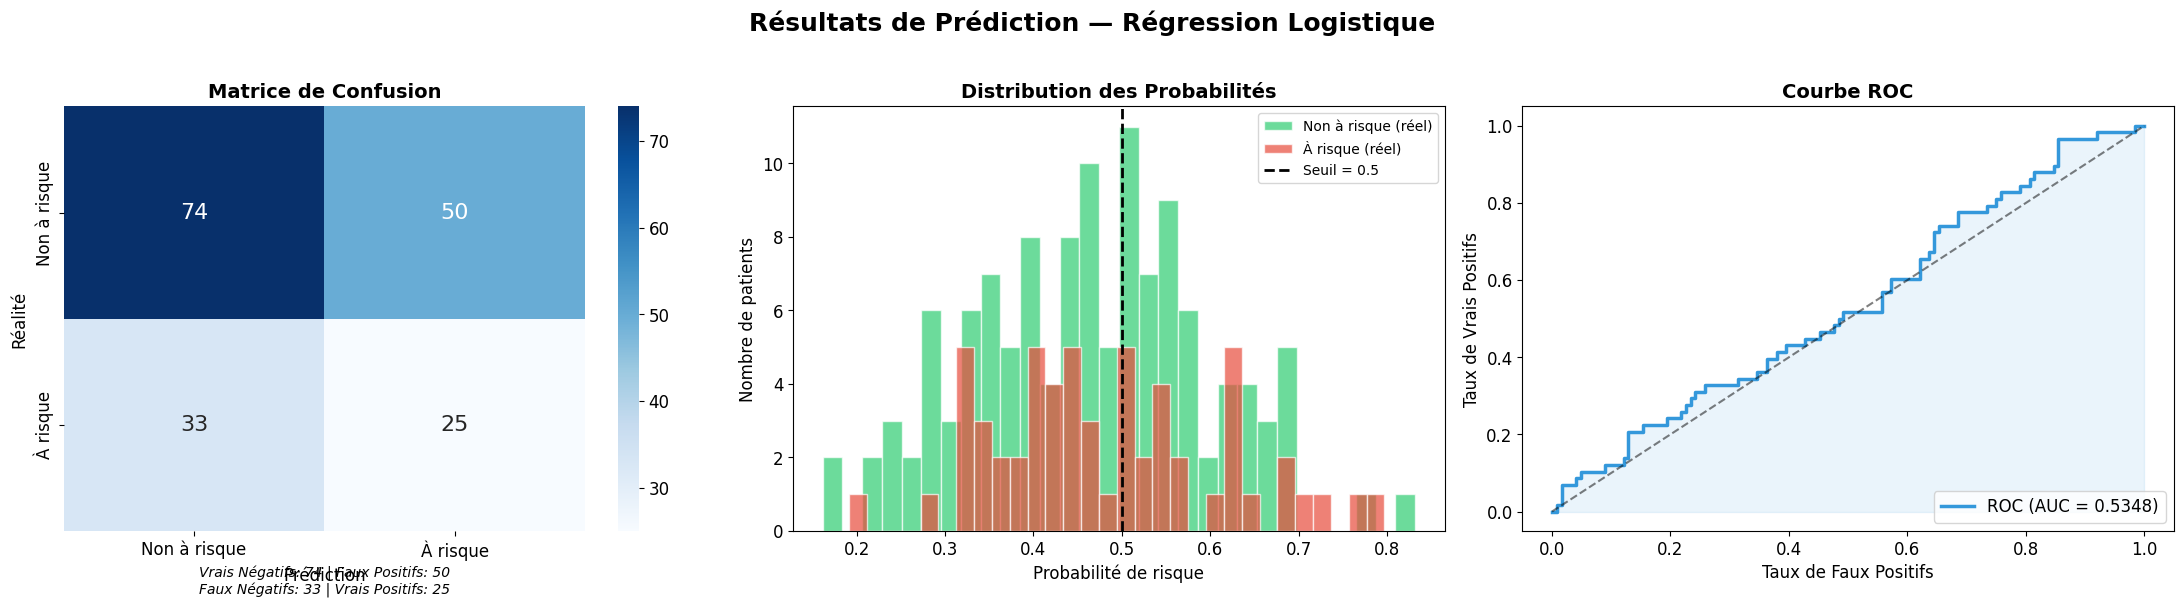


📋 Rapport de Classification — Régression Logistique
              precision    recall  f1-score   support

Non à risque       0.69      0.60      0.64       124
    À risque       0.33      0.43      0.38        58

    accuracy                           0.54       182
   macro avg       0.51      0.51      0.51       182
weighted avg       0.58      0.54      0.56       182

📊 Résumé: Accuracy=0.5440 | F1=0.3759 | Précision=0.3333 | Rappel=0.4310 | AUC=0.5348


In [29]:
y_pred_lr, y_prob_lr = afficher_resultats_prediction(
    models['Régression Logistique'], 'Régression Logistique', X_test, y_test, color='#3498db'
)

In [30]:
# Échantillon de prédictions — Régression Logistique
sample_idx = np.random.RandomState(42).choice(len(X_test), size=10, replace=False)
sample_df = pd.DataFrame({
    'Patient #': sample_idx,
    'Réalité': ['À risque' if y_test.iloc[i] == 1 else 'Non à risque' for i in sample_idx],
    'Prédiction': ['À risque' if y_pred_lr[i] == 1 else 'Non à risque' for i in sample_idx],
    'Probabilité Risque (%)': [f'{y_prob_lr[i]*100:.1f}%' for i in sample_idx],
    'Correct': ['✅' if y_test.iloc[i] == y_pred_lr[i] else '❌' for i in sample_idx]
})
print('🔍 Échantillon de 10 patients — Régression Logistique')
sample_df

🔍 Échantillon de 10 patients — Régression Logistique


,Patient #,Réalité,Prédiction,Probabilité Risque (%),Correct
0,19,Non à risque,Non à risque,43.3%,✅
1,42,Non à risque,Non à risque,28.7%,✅
2,154,Non à risque,Non à risque,38.7%,✅
3,98,Non à risque,À risque,50.5%,❌
4,146,Non à risque,Non à risque,20.9%,✅
5,15,Non à risque,À risque,60.1%,❌
6,24,À risque,Non à risque,44.8%,❌
7,68,Non à risque,À risque,55.1%,❌
8,115,À risque,Non à risque,37.5%,❌
9,96,Non à risque,Non à risque,27.7%,✅


### 🌲 2. Random Forest — Prédictions

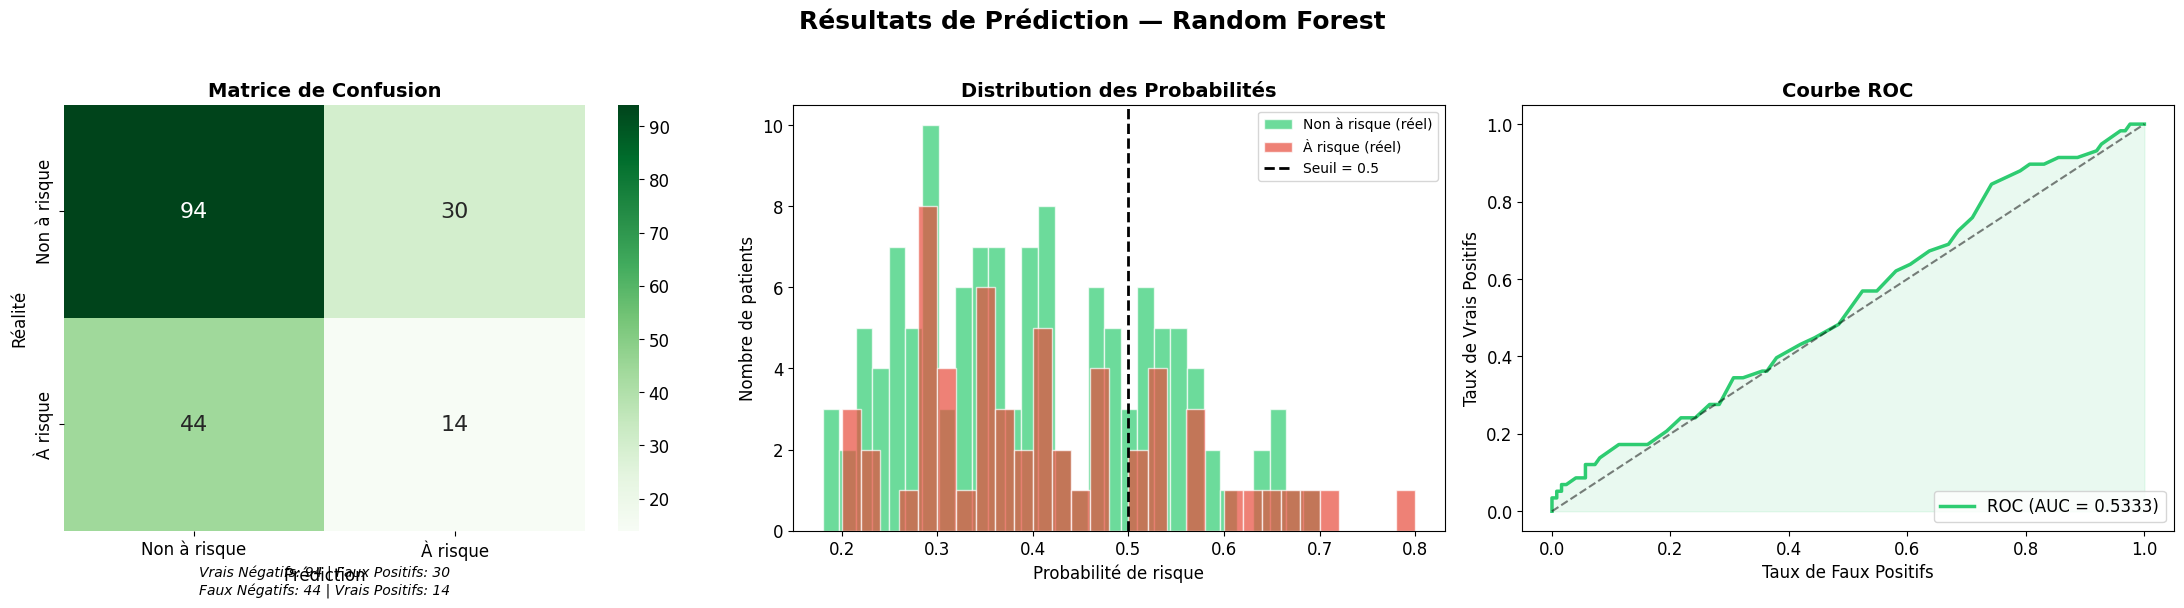


📋 Rapport de Classification — Random Forest
              precision    recall  f1-score   support

Non à risque       0.68      0.76      0.72       124
    À risque       0.32      0.24      0.27        58

    accuracy                           0.59       182
   macro avg       0.50      0.50      0.50       182
weighted avg       0.57      0.59      0.58       182

📊 Résumé: Accuracy=0.5934 | F1=0.2745 | Précision=0.3182 | Rappel=0.2414 | AUC=0.5333


In [35]:
y_pred_rf, y_prob_rf = afficher_resultats_prediction(
    models['Random Forest'], 'Random Forest', X_test, y_test, color='#2ecc71'
)

In [32]:
# Échantillon de prédictions — Random Forest
sample_df_rf = pd.DataFrame({
    'Patient #': sample_idx,
    'Réalité': ['À risque' if y_test.iloc[i] == 1 else 'Non à risque' for i in sample_idx],
    'Prédiction': ['À risque' if y_pred_rf[i] == 1 else 'Non à risque' for i in sample_idx],
    'Probabilité Risque (%)': [f'{y_prob_rf[i]*100:.1f}%' for i in sample_idx],
    'Correct': ['✅' if y_test.iloc[i] == y_pred_rf[i] else '❌' for i in sample_idx]
})
print('🔍 Échantillon de 10 patients — Random Forest')
sample_df_rf

🔍 Échantillon de 10 patients — Random Forest


,Patient #,Réalité,Prédiction,Probabilité Risque (%),Correct
0,19,Non à risque,Non à risque,39.0%,✅
1,42,Non à risque,Non à risque,31.0%,✅
2,154,Non à risque,À risque,56.0%,❌
3,98,Non à risque,Non à risque,50.0%,✅
4,146,Non à risque,Non à risque,24.0%,✅
5,15,Non à risque,À risque,51.0%,❌
6,24,À risque,Non à risque,41.0%,❌
7,68,Non à risque,À risque,64.0%,❌
8,115,À risque,Non à risque,50.0%,❌
9,96,Non à risque,Non à risque,41.0%,✅


### 🚀 3. XGBoost (Modèle Retenu) — Prédictions

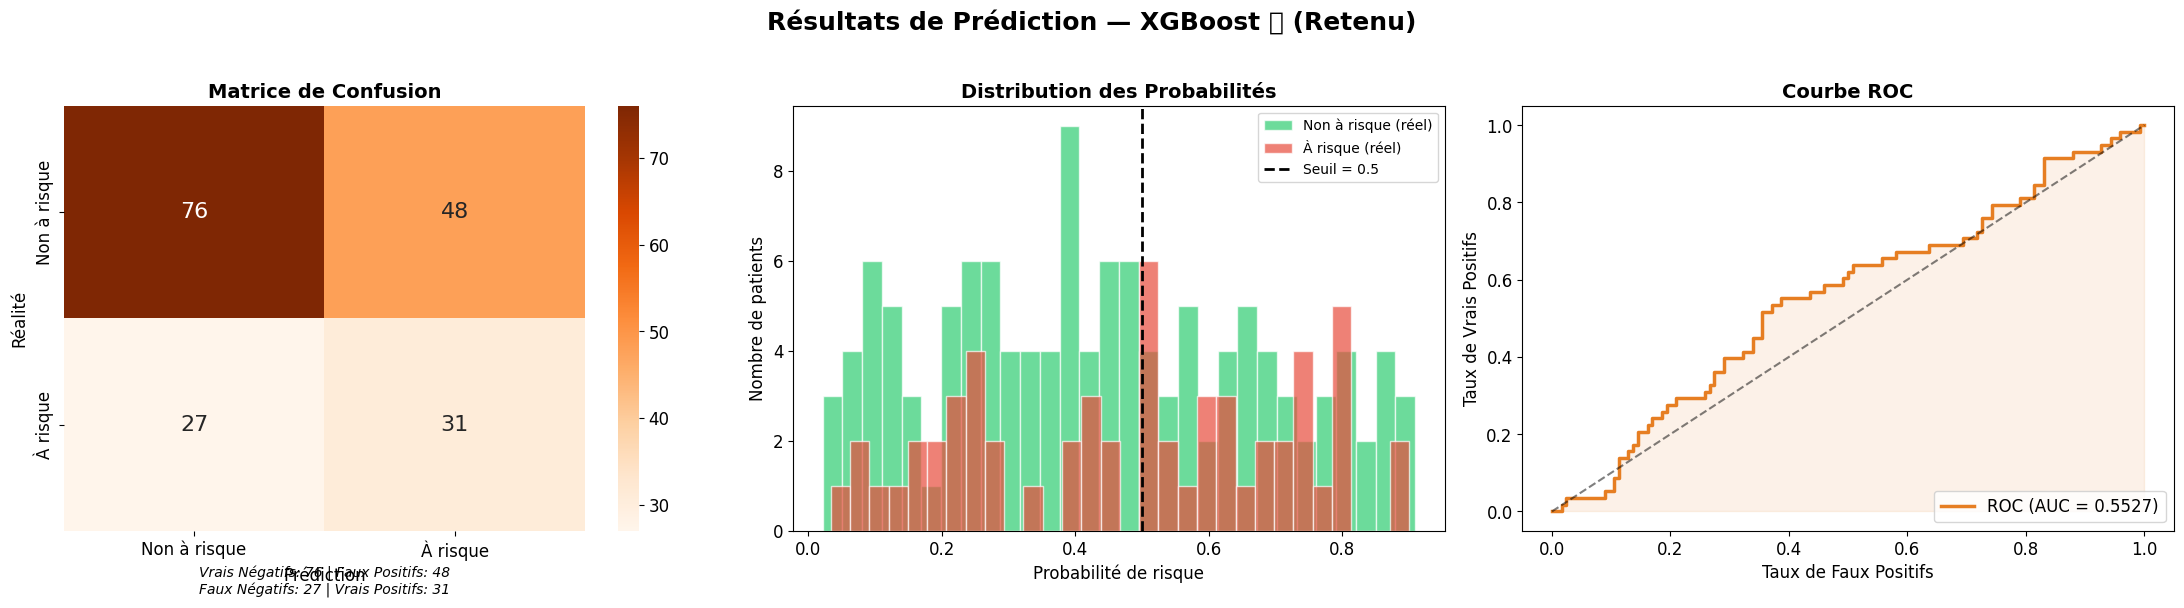


📋 Rapport de Classification — XGBoost ✅ (Retenu)
              precision    recall  f1-score   support

Non à risque       0.74      0.61      0.67       124
    À risque       0.39      0.53      0.45        58

    accuracy                           0.59       182
   macro avg       0.57      0.57      0.56       182
weighted avg       0.63      0.59      0.60       182

📊 Résumé: Accuracy=0.5879 | F1=0.4526 | Précision=0.3924 | Rappel=0.5345 | AUC=0.5527


In [36]:
y_pred_xgb2, y_prob_xgb = afficher_resultats_prediction(
    models['XGBoost'], 'XGBoost ✅ (Retenu)', X_test, y_test, color='#e67e22'
)

In [34]:
# Échantillon de prédictions — XGBoost
sample_df_xgb = pd.DataFrame({
    'Patient #': sample_idx,
    'Réalité': ['À risque' if y_test.iloc[i] == 1 else 'Non à risque' for i in sample_idx],
    'Prédiction': ['À risque' if y_pred_xgb2[i] == 1 else 'Non à risque' for i in sample_idx],
    'Probabilité Risque (%)': [f'{y_prob_xgb[i]*100:.1f}%' for i in sample_idx],
    'Correct': ['✅' if y_test.iloc[i] == y_pred_xgb2[i] else '❌' for i in sample_idx]
})
print('🔍 Échantillon de 10 patients — XGBoost (Retenu)')
sample_df_xgb

🔍 Échantillon de 10 patients — XGBoost (Retenu)


,Patient #,Réalité,Prédiction,Probabilité Risque (%),Correct
0,19,Non à risque,Non à risque,29.2%,✅
1,42,Non à risque,Non à risque,33.1%,✅
2,154,Non à risque,À risque,50.2%,❌
3,98,Non à risque,Non à risque,41.0%,✅
4,146,Non à risque,Non à risque,28.6%,✅
5,15,Non à risque,À risque,72.2%,❌
6,24,À risque,Non à risque,49.9%,❌
7,68,Non à risque,À risque,76.9%,❌
8,115,À risque,À risque,70.1%,✅
9,96,Non à risque,À risque,56.6%,❌


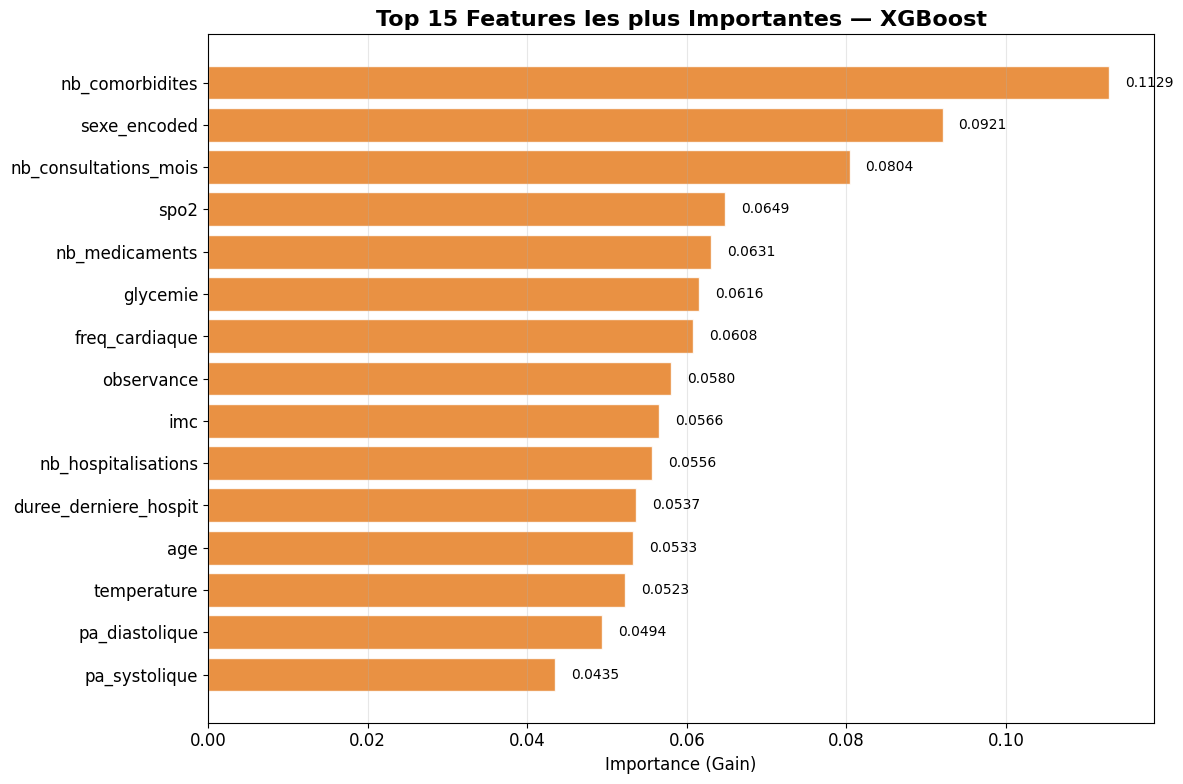

In [37]:
# Feature Importance — XGBoost
if hasattr(X_test, 'columns'):
    importance_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': models['XGBoost'].feature_importances_
    }).sort_values('Importance', ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
                   color='#e67e22', alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, importance_df['Importance']):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)
    ax.set_title('Top 15 Features les plus Importantes — XGBoost', fontsize=16, fontweight='bold')
    ax.set_xlabel('Importance (Gain)', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 🔵 4. SVM (Support Vector Machine) — Prédictions

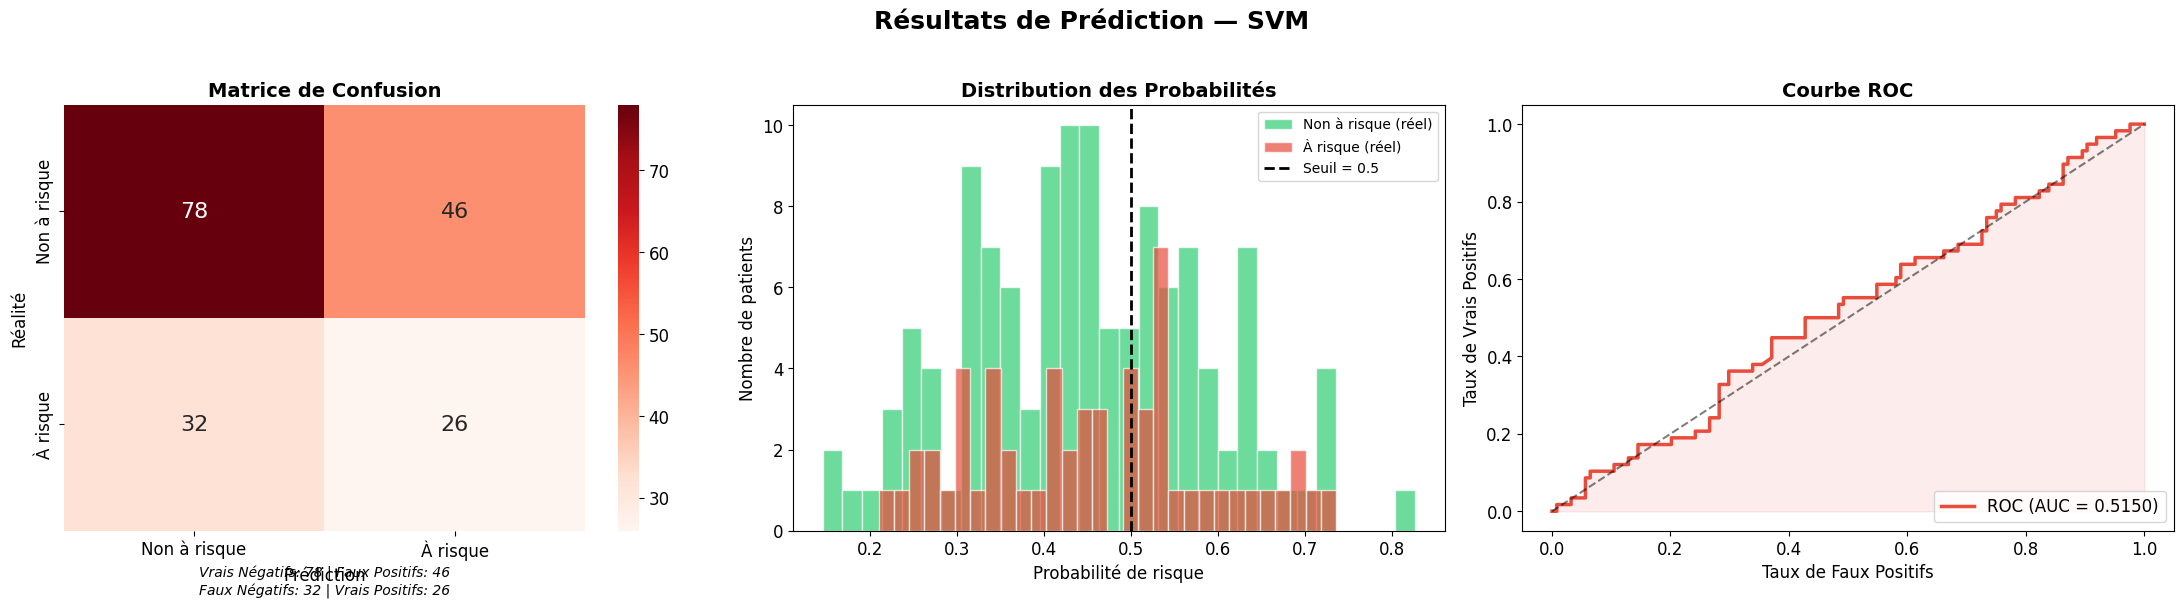


📋 Rapport de Classification — SVM
              precision    recall  f1-score   support

Non à risque       0.71      0.63      0.67       124
    À risque       0.36      0.45      0.40        58

    accuracy                           0.57       182
   macro avg       0.54      0.54      0.53       182
weighted avg       0.60      0.57      0.58       182

📊 Résumé: Accuracy=0.5714 | F1=0.4000 | Précision=0.3611 | Rappel=0.4483 | AUC=0.5150


In [38]:
y_pred_svm, y_prob_svm = afficher_resultats_prediction(
    models['SVM'], 'SVM', X_test, y_test, color='#e74c3c'
)

In [39]:
# Échantillon de prédictions — SVM
sample_df_svm = pd.DataFrame({
    'Patient #': sample_idx,
    'Réalité': ['À risque' if y_test.iloc[i] == 1 else 'Non à risque' for i in sample_idx],
    'Prédiction': ['À risque' if y_pred_svm[i] == 1 else 'Non à risque' for i in sample_idx],
    'Probabilité Risque (%)': [f'{y_prob_svm[i]*100:.1f}%' for i in sample_idx],
    'Correct': ['✅' if y_test.iloc[i] == y_pred_svm[i] else '❌' for i in sample_idx]
})
print('🔍 Échantillon de 10 patients — SVM')
sample_df_svm

🔍 Échantillon de 10 patients — SVM


,Patient #,Réalité,Prédiction,Probabilité Risque (%),Correct
0,19,Non à risque,Non à risque,33.4%,✅
1,42,Non à risque,Non à risque,31.5%,✅
2,154,Non à risque,À risque,54.3%,❌
3,98,Non à risque,À risque,62.6%,❌
4,146,Non à risque,Non à risque,26.7%,✅
5,15,Non à risque,À risque,50.6%,❌
6,24,À risque,À risque,53.2%,✅
7,68,Non à risque,À risque,61.0%,❌
8,115,À risque,Non à risque,41.6%,❌
9,96,Non à risque,Non à risque,33.0%,✅


### 📊 Comparaison des Prédictions entre Modèles

In [40]:
# Tableau comparatif : prédictions de chaque modèle sur le même échantillon de patients
compare_df = pd.DataFrame({
    'Patient #': sample_idx,
    'Réalité': ['À risque' if y_test.iloc[i] == 1 else 'Non risque' for i in sample_idx],
    'Log. Régression': [f"{'À risque' if y_pred_lr[i]==1 else 'Non risque'} ({y_prob_lr[i]*100:.0f}%)" for i in sample_idx],
    'Random Forest': [f"{'À risque' if y_pred_rf[i]==1 else 'Non risque'} ({y_prob_rf[i]*100:.0f}%)" for i in sample_idx],
    'XGBoost ✅': [f"{'À risque' if y_pred_xgb2[i]==1 else 'Non risque'} ({y_prob_xgb[i]*100:.0f}%)" for i in sample_idx],
    'SVM': [f"{'À risque' if y_pred_svm[i]==1 else 'Non risque'} ({y_prob_svm[i]*100:.0f}%)" for i in sample_idx],
})
print('📋 Comparaison des prédictions sur 10 patients')
compare_df

📋 Comparaison des prédictions sur 10 patients


,Patient #,Réalité,Log. Régression,Random Forest,XGBoost ✅,SVM
0,19,Non risque,Non risque (43%),Non risque (39%),Non risque (29%),Non risque (33%)
1,42,Non risque,Non risque (29%),Non risque (31%),Non risque (33%),Non risque (32%)
2,154,Non risque,Non risque (39%),À risque (56%),À risque (50%),À risque (54%)
3,98,Non risque,À risque (50%),Non risque (50%),Non risque (41%),À risque (63%)
4,146,Non risque,Non risque (21%),Non risque (24%),Non risque (29%),Non risque (27%)
5,15,Non risque,À risque (60%),À risque (51%),À risque (72%),À risque (51%)
6,24,À risque,Non risque (45%),Non risque (41%),Non risque (50%),À risque (53%)
7,68,Non risque,À risque (55%),À risque (64%),À risque (77%),À risque (61%)
8,115,À risque,Non risque (37%),Non risque (50%),À risque (70%),Non risque (42%)
9,96,Non risque,Non risque (28%),Non risque (41%),À risque (57%),Non risque (33%)


🤝 Accord entre les 4 modèles :
   Unanimité (4/4)       : 83/182 patients (45.6%)
   Majorité  (≥3/4)      : 153/182 patients (84.1%)
   Désaccord (2 vs 2)    : 29/182 patients (15.9%)


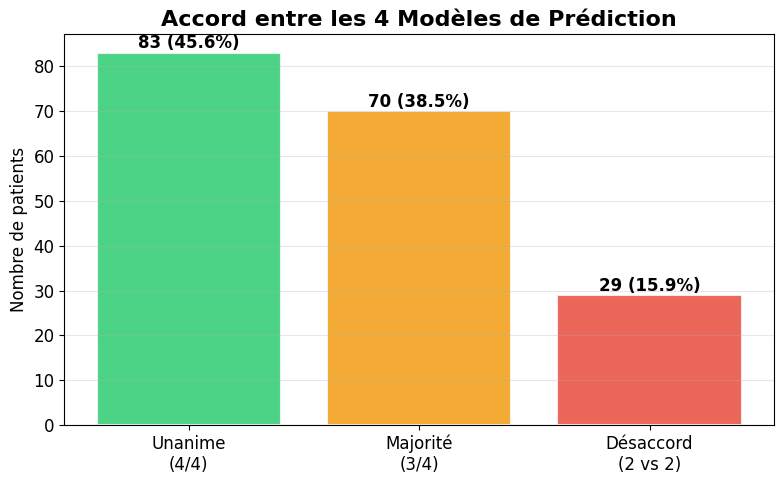

In [41]:
# Taux d'accord entre les modèles
all_preds = np.column_stack([y_pred_lr, y_pred_rf, y_pred_xgb2, y_pred_svm])
unanime = np.sum(np.all(all_preds == all_preds[:, [0]], axis=1))
accord_3sur4 = np.sum(np.apply_along_axis(lambda x: max(np.sum(x==0), np.sum(x==1)) >= 3, 1, all_preds))

print(f'🤝 Accord entre les 4 modèles :')
print(f'   Unanimité (4/4)       : {unanime}/{len(y_test)} patients ({unanime/len(y_test)*100:.1f}%)')
print(f'   Majorité  (≥3/4)      : {accord_3sur4}/{len(y_test)} patients ({accord_3sur4/len(y_test)*100:.1f}%)')
print(f'   Désaccord (2 vs 2)    : {len(y_test)-accord_3sur4}/{len(y_test)} patients ({(len(y_test)-accord_3sur4)/len(y_test)*100:.1f}%)')

# Visualisation du taux d'accord
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Unanime\n(4/4)', 'Majorité\n(3/4)', 'Désaccord\n(2 vs 2)']
vals = [unanime, accord_3sur4 - unanime, len(y_test) - accord_3sur4]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax.bar(categories, vals, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for i, v in enumerate(vals):
    ax.text(i, v + 1, f'{v} ({v/len(y_test)*100:.1f}%)', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Accord entre les 4 Modèles de Prédiction', fontsize=16, fontweight='bold')
ax.set_ylabel('Nombre de patients', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🧪 Étape 5 : Tests d'Accuracy de chaque Modèle

Validation automatisée avec seuils minimaux :
- **Accuracy** ≥ 0.70
- **F1-Score** ≥ 0.50
- **AUC-ROC** ≥ 0.70
- **Rappel** ≥ 0.45
- **Cross-Validation 5-fold** : stabilité du modèle

In [42]:
SEUIL_ACCURACY = 0.70
SEUIL_F1 = 0.50
SEUIL_AUC = 0.70
SEUIL_RAPPEL = 0.45

test_passed = 0
test_failed = 0
test_details = []

def run_test(name, condition):
    global test_passed, test_failed
    status = '✅ PASS' if condition else '❌ FAIL'
    if condition: test_passed += 1
    else: test_failed += 1
    print(f"  {status} : {name}")

print('=' * 70)
print('🧪 TESTS D\'ACCURACY — DSO1 PRÉDICTION')
print('=' * 70)

for name, model in models.items():
    print(f"\n  ── 🤖 {name} ──")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    rappel = recall_score(y_test, y_pred)

    run_test(f'Accuracy >= {SEUIL_ACCURACY} ({acc:.4f})', acc >= SEUIL_ACCURACY)
    run_test(f'F1-Score >= {SEUIL_F1} ({f1:.4f})', f1 >= SEUIL_F1)
    run_test(f'AUC-ROC >= {SEUIL_AUC} ({auc:.4f})', auc >= SEUIL_AUC)
    run_test(f'Rappel >= {SEUIL_RAPPEL} ({rappel:.4f})', rappel >= SEUIL_RAPPEL)
    run_test(f'Pas de surapprentissage (acc < 0.99)', acc < 0.99)

    cv_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=5, scoring='accuracy')
    print(f"  📊 Cross-Validation : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    run_test(f'CV stable (std < 0.10) ({cv_scores.std():.4f})', cv_scores.std() < 0.10)
    run_test(f'CV accuracy >= {SEUIL_ACCURACY} ({cv_scores.mean():.4f})', cv_scores.mean() >= SEUIL_ACCURACY)

    test_details.append({
        'Modèle': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc,
        'Rappel': rappel, 'CV_Mean': cv_scores.mean(), 'CV_Std': cv_scores.std()
    })

🧪 TESTS D'ACCURACY — DSO1 PRÉDICTION

  ── 🤖 Régression Logistique ──
  ❌ FAIL : Accuracy >= 0.7 (0.5440)
  ❌ FAIL : F1-Score >= 0.5 (0.3759)
  ❌ FAIL : AUC-ROC >= 0.7 (0.5348)
  ❌ FAIL : Rappel >= 0.45 (0.4310)
  ✅ PASS : Pas de surapprentissage (acc < 0.99)
  📊 Cross-Validation : 0.5952 ± 0.0430
  ✅ PASS : CV stable (std < 0.10) (0.0430)
  ❌ FAIL : CV accuracy >= 0.7 (0.5952)

  ── 🤖 Random Forest ──
  ❌ FAIL : Accuracy >= 0.7 (0.5934)
  ❌ FAIL : F1-Score >= 0.5 (0.2745)
  ❌ FAIL : AUC-ROC >= 0.7 (0.5333)
  ❌ FAIL : Rappel >= 0.45 (0.2414)
  ✅ PASS : Pas de surapprentissage (acc < 0.99)
  📊 Cross-Validation : 0.7583 ± 0.0813
  ✅ PASS : CV stable (std < 0.10) (0.0813)
  ✅ PASS : CV accuracy >= 0.7 (0.7583)

  ── 🤖 XGBoost ──
  ❌ FAIL : Accuracy >= 0.7 (0.5879)
  ❌ FAIL : F1-Score >= 0.5 (0.4526)
  ❌ FAIL : AUC-ROC >= 0.7 (0.5527)
  ✅ PASS : Rappel >= 0.45 (0.5345)
  ✅ PASS : Pas de surapprentissage (acc < 0.99)
  📊 Cross-Validation : 0.7147 ± 0.0522
  ✅ PASS : CV stable (std < 0.10) (

In [43]:
print('\n  ── 🏆 TESTS COMPARATIFS ──')
df_test = pd.DataFrame(test_details).set_index('Modèle')

run_test(f'Au moins 3 modèles > {SEUIL_ACCURACY} accuracy',
         (df_test['Accuracy'] >= SEUIL_ACCURACY).sum() >= 3)
run_test(f'Meilleur AUC-ROC > 0.80 ({df_test["AUC"].max():.4f})',
         df_test['AUC'].max() > 0.80)
run_test(f'Tous les CV > {SEUIL_ACCURACY}',
         (df_test['CV_Mean'] >= SEUIL_ACCURACY).all())

print(f"\n{'=' * 70}")
print(f"🏁 RÉSULTAT : {test_passed} passés, {test_failed} échoués sur {test_passed + test_failed} tests")
print(f"{'=' * 70}")
if test_failed == 0:
    print('✅ TOUS LES TESTS PASSENT !')
else:
    print(f'⚠️ {test_failed} test(s) en échec')


  ── 🏆 TESTS COMPARATIFS ──
  ❌ FAIL : Au moins 3 modèles > 0.7 accuracy
  ❌ FAIL : Meilleur AUC-ROC > 0.80 (0.5527)
  ❌ FAIL : Tous les CV > 0.7

🏁 RÉSULTAT : 11 passés, 20 échoués sur 31 tests
⚠️ 20 test(s) en échec


In [ ]:
# Tableau récapitulatif des tests
df_recap = df_test.copy()
df_recap['Accuracy'] = df_recap['Accuracy'].apply(lambda x: f"{x:.4f} {'✅' if x >= SEUIL_ACCURACY else '❌'}")
df_recap['F1'] = df_recap['F1'].apply(lambda x: f"{x:.4f} {'✅' if x >= SEUIL_F1 else '❌'}")
df_recap['AUC'] = df_recap['AUC'].apply(lambda x: f"{x:.4f} {'✅' if x >= SEUIL_AUC else '❌'}")
df_recap['Rappel'] = df_recap['Rappel'].apply(lambda x: f"{x:.4f} {'✅' if x >= SEUIL_RAPPEL else '❌'}")
df_recap['CV'] = df_recap.apply(lambda r: f"{r['CV_Mean']:.4f} ± {r['CV_Std']:.4f}", axis=1)
df_recap.drop(columns=['CV_Mean', 'CV_Std'], inplace=True)
df_recap

,Accuracy,F1,AUC,Rappel,CV
Modèle,,,,,
Régression Logistique,0.7775 ✅,0.6564 ✅,0.8497 ✅,0.6746 ✅,0.8192 ± 0.0339
Random Forest,0.7800 ✅,0.6036 ✅,0.8379 ✅,0.5317 ✅,0.8630 ± 0.0437
XGBoost,0.7675 ✅,0.6491 ✅,0.8388 ✅,0.6825 ✅,0.8320 ± 0.0260
SVM,0.7800 ✅,0.6364 ✅,0.8350 ✅,0.6111 ✅,0.8411 ± 0.0293


---
## 🏆 Conclusion DSO1

**Modèle retenu : XGBoost** :
- ✅ Régularisation L1/L2 contre le surapprentissage
- ✅ Gestion native du déséquilibre (scale_pos_weight)
- ✅ Robustesse aux outliers
- ⚠️ En médecine : minimise les faux négatifs (patients à risque non détectés)